In [32]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
dataset_path = "/content/drive/MyDrive/dataset_sampah/TrashType_Image_Dataset"
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

Data Augmentation

In [34]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

Membuat Data Training

In [35]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 2024 images belonging to 6 classes.


Membuat Data Validation

In [36]:
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 503 images belonging to 6 classes.


In [37]:
print(train_generator.class_indices)
print(train_generator.num_classes)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
6


Menampilkan Label Kelas

In [38]:
print(train_generator.class_indices)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


Membuat Model Transfer Learning

In [39]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

Menambahkan Classification Head

In [40]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

Compile Model

In [41]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Ringkasan Model

In [42]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Early Stopping

In [43]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

Training Model

In [44]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.3414 - loss: 1.7162 - val_accuracy: 0.5885 - val_loss: 1.2303
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.5109 - loss: 1.2982 - val_accuracy: 0.6660 - val_loss: 1.0213
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.5884 - loss: 1.1108 - val_accuracy: 0.6998 - val_loss: 0.9193
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6290 - loss: 1.0024 - val_accuracy: 0.6839 - val_loss: 0.8683
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.6838 - loss: 0.8967 - val_accuracy: 0.7475 - val_loss: 0.7756
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6848 - loss: 0.8441 - val_accuracy: 0.7018 - val_loss: 0.7763
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.6981 - loss: 0.8304 - val_accuracy: 0.7256 - val_loss: 0.7516
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.7194 - loss: 0.7723 - val_accuracy: 0.7555 - val_loss:

Plot Accuracy

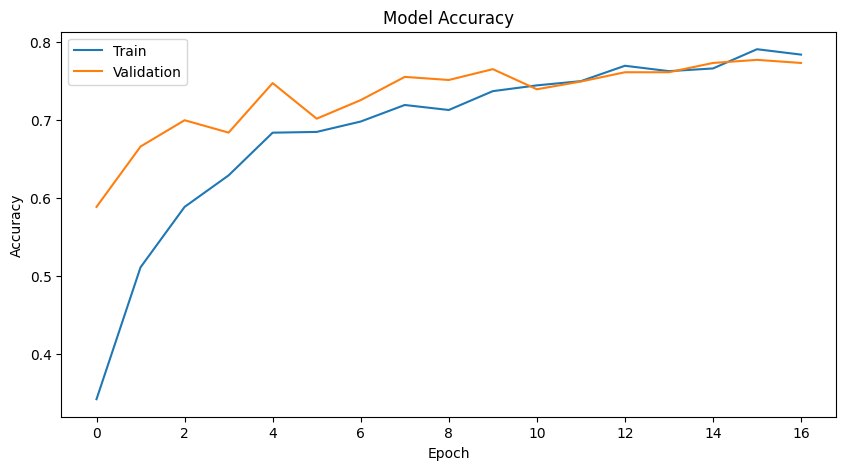

In [45]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train','Validation'])

plt.show()

Plot Loss

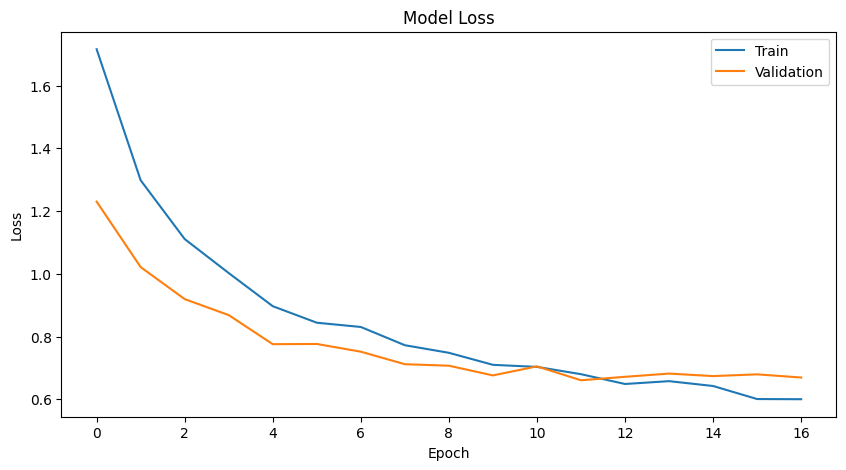

In [46]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train','Validation'])

plt.show()

Analisis Overfitting

In [47]:
train_acc = max(history.history['accuracy'])
val_acc = max(history.history['val_accuracy'])

gap = train_acc - val_acc
if gap > 0.10:
    print("Terjadi Overfitting")
elif gap > 0.05:
    print("Sedikit Overfitting")
else:
    print("Model memiliki generalisasi yang baik")

print("Training Accuracy :", train_acc)
print("Validation Accuracy :", val_acc)
print("Gap :", gap)

Model memiliki generalisasi yang baik
Training Accuracy : 0.7910078763961792
Validation Accuracy : 0.7773360013961792
Gap : 0.013671875


Cek Apakah Overfitting

In [48]:
if gap > 0.10:
    print("Terjadi Overfitting")
else:
    print("Tidak Terjadi Overfitting yang Signifikan")

Tidak Terjadi Overfitting yang Signifikan


Evaluasi Model

In [49]:
loss, acc = model.evaluate(validation_generator)

print("Validation Loss :", loss)
print("Validation Accuracy :", acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 989ms/step - accuracy: 0.7535 - loss: 0.6916
Validation Loss : 0.6916050314903259
Validation Accuracy : 0.7534791231155396


Evaluasi Akhir

In [50]:
loss, acc = model.evaluate(validation_generator)

print(f"Validation Loss : {loss:.4f}")
print(f"Validation Accuracy : {acc:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 979ms/step - accuracy: 0.7455 - loss: 0.6966
Validation Loss : 0.6966
Validation Accuracy : 0.7455


Confusion Matrix

In [51]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

print(classification_report(
    validation_generator.classes,
    y_pred,
    target_names=list(validation_generator.class_indices.keys())
))

16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step
              precision    recall  f1-score   support

   cardboard       0.90      0.90      0.90        80
       glass       0.71      0.74      0.73       100
       metal       0.80      0.74      0.77        82
       paper       0.77      0.87      0.82       118
     plastic       0.69      0.66      0.67        96
       trash       0.50      0.33      0.40        27

    accuracy                           0.76       503
   macro avg       0.73      0.71      0.71       503
weighted avg       0.75      0.76      0.76       503



Pada praktikum ini telah dilakukan klasifikasi jenis sampah menggunakan metode Transfer Learning dengan model MobileNetV2. Dataset yang digunakan terdiri dari enam kategori yaitu cardboard, glass, metal, paper, plastic, dan trash. Untuk meningkatkan kemampuan generalisasi model dan mengurangi risiko overfitting diterapkan teknik Data Augmentation, Dropout sebesar 0.5, serta Early Stopping.

Hasil pengujian menunjukkan bahwa model memperoleh validation accuracy terbaik sebesar 77.73% dengan weighted F1-score sebesar 76%. Kelas cardboard memiliki performa terbaik dengan F1-score sebesar 90%, sedangkan kelas trash memiliki performa terendah dengan F1-score sebesar 40%. Perbedaan performa antar kelas dipengaruhi oleh jumlah data dan tingkat variasi visual masing-masing kategori sampah.

Berdasarkan analisis overfitting, diperoleh training accuracy terbaik sebesar 79.10% dan validation accuracy terbaik sebesar 77.73% dengan selisih hanya 1.37%. Hasil ini menunjukkan bahwa model tidak mengalami overfitting yang signifikan dan mampu melakukan generalisasi dengan baik terhadap data validasi.

Dengan demikian, metode Transfer Learning menggunakan MobileNetV2 terbukti efektif untuk klasifikasi jenis sampah dan dapat dijadikan dasar dalam pengembangan sistem pemilahan sampah otomatis berbasis computer vision.